# SmolLM3 Eval Comparison
Set `CHECKPOINTS_ROOT` and `RUN_SPECS` below, where each run is just `(run_name, "hf" | "sft_openthoughts")`, then run all cells to inspect the combined tables + plots for every run.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

from plot_eval_comparison import load_run, RunInfo

In [2]:
CHECKPOINTS_ROOT = Path("/iopsstor/scratch/cscs/kponkshe/sb-decay/checkpoints")
BASE_MODEL_ROOT = Path("/iopsstor/scratch/cscs/kponkshe/sb-decay/ckpts/SmolLM3-3B/stage2-step-4200000/hf")


RUN_SPECS = [
    ("run_decay_dolma", "hf"),
    ("run_stable_dolma", "hf"),
    ("run_decay_dolma_no_reasoning", "hf"),
    ("run_stable_dolma_no_reasoning", "hf"),
]

SFT_DELTA_BASES = [
    CHECKPOINTS_ROOT / "run_decay_dolma",
    CHECKPOINTS_ROOT / "run_stable_dolma",
    CHECKPOINTS_ROOT / "run_decay_dolma_no_reasoning",
    CHECKPOINTS_ROOT / "run_stable_dolma_no_reasoning",
]

BASE_VS_MIDTRAIN_SPECS = [
    ("run_decay_dolma", "hf"),
    ("run_stable_dolma", "hf"),
    ("run_decay_dolma_no_reasoning", "hf"),
    ("run_stable_dolma_no_reasoning", "hf"),
]

BASE_VS_SFT_SPECS = [
    ("run_decay_dolma", "sft_openthoughts"),
    ("run_stable_dolma", "sft_openthoughts"),
    ("run_decay_dolma_no_reasoning", "sft_openthoughts"),
    ("run_stable_dolma_no_reasoning", "sft_openthoughts"),
]

In [3]:
def extract_run_label(path: Path) -> str:
    match = re.search(r"/(run_[^/]+)", str(path))
    if not match:
        return path.name

    label = match.group(1).removeprefix("run_")
    label = re.sub(r"_dolma(?=_|$)", "", label)
    label = label.replace("_no_reasoning", " (no reasoning)")
    label = label.replace("_", " ")
    return re.sub(r"\s+", " ", label).strip()


def checkpoint_number(path: Path) -> int:
    match = re.search(r"checkpoint-(\d+)", path.name)
    if not match:
        return -1
    return int(match.group(1))


def normalize_base_path(base_spec: str | Path) -> Path:
    if isinstance(base_spec, Path):
        return base_spec

    base_path = Path(base_spec)
    if base_path.is_absolute() or len(base_path.parts) > 1:
        return base_path
    return CHECKPOINTS_ROOT / base_path


def normalize_run_spec(spec: tuple[str, str] | dict[str, Path | str]) -> dict[str, Path | str]:
    if isinstance(spec, tuple):
        run_name, eval_target = spec
        return {
            "base_path": normalize_base_path(run_name),
            "eval_target": eval_target,
        }

    if isinstance(spec, dict):
        return {
            "base_path": normalize_base_path(spec["base_path"]),
            "eval_target": spec["eval_target"],
        }

    raise TypeError(f"Unsupported RUN_SPECS entry: {spec!r}")


def resolve_eval_root(base_path: Path, eval_target: str) -> Path:
    if eval_target == "hf":
        direct_eval_root = base_path / "evals" / "lm_eval" / "base"
        if direct_eval_root.exists():
            return direct_eval_root

        eval_root = base_path / "hf" / "evals" / "lm_eval" / "base"
        if not eval_root.exists():
            raise FileNotFoundError(f"No hf eval directory found under: {base_path}")
        return eval_root

    if eval_target == "sft_openthoughts":
        sft_root = base_path / "sft_openthoughts"
        if not sft_root.exists():
            raise FileNotFoundError(f"No sft_openthoughts directory found under: {base_path}")

        checkpoints = sorted(
            [p for p in sft_root.iterdir() if p.is_dir() and p.name.startswith("checkpoint-")],
            key=checkpoint_number,
            reverse=True,
        )
        for checkpoint_dir in checkpoints:
            eval_root = checkpoint_dir / "evals" / "lm_eval" / "base"
            if eval_root.exists():
                return eval_root

        raise FileNotFoundError(f"No checkpoint eval directory found under: {sft_root}")

    raise ValueError(f"Unsupported eval_target: {eval_target}")


def format_eval_target(eval_target: str) -> str:
    labels = {
        "hf": "pretrained",
        "sft_openthoughts": "post trained",
    }
    return labels.get(eval_target, eval_target)


def build_run_labels(run_specs: list[dict[str, Path | str]]) -> list[str]:
    base_labels = [extract_run_label(spec["base_path"]) for spec in run_specs]
    label_counts = pd.Series(base_labels).value_counts().to_dict()

    labels = []
    for spec, base_label in zip(run_specs, base_labels):
        if label_counts[base_label] > 1:
            labels.append(f"{base_label} ({format_eval_target(spec['eval_target'])})")
        else:
            labels.append(base_label)

    seen: dict[str, int] = {}
    unique_labels: list[str] = []
    for label in labels:
        seen[label] = seen.get(label, 0) + 1
        suffix = f" ({seen[label]})" if seen[label] > 1 else ""
        unique_labels.append(f"{label}{suffix}")
    return unique_labels


def make_task_label(task: str, num_fewshot: float | int | None) -> str:
    if num_fewshot is None:
        return task
    try:
        if pd.isna(num_fewshot):
            return task
    except TypeError:
        pass
    if num_fewshot == 0:
        return task
    return f"{task} ({int(num_fewshot)}-shot)"


def should_keep_task(task: str) -> bool:
    task_lower = task.lower()
    if task_lower in {"mmlu", "mmlu_pro"}:
        return True
    if task_lower.startswith("mmlu_") or task_lower.startswith("mmlu:"):
        return False
    if task_lower.startswith("mmlu_pro_") or task_lower.startswith("mmlu_pro:"):
        return False
    return True


def load_task_scores(base_path: Path, eval_target: str, label: str) -> pd.DataFrame:
    eval_root = resolve_eval_root(base_path, eval_target)
    run_df = load_run(RunInfo(label=label, root=eval_root)).copy()
    run_scores = (
        run_df[["task", "num_fewshot", "task_label", "value"]]
        .rename(columns={"value": label})
        .drop_duplicates(subset=["task", "num_fewshot"], keep="last")
    )
    run_scores = run_scores.loc[run_scores["task"].map(should_keep_task)].copy()
    return run_scores.sort_values(["task", "num_fewshot"]).reset_index(drop=True)


def build_comparison(run_specs: list[tuple[str, str] | dict[str, Path | str]]) -> tuple[list[str], pd.DataFrame, pd.DataFrame]:
    if len(run_specs) < 2:
        raise ValueError("Provide at least two entries in RUN_SPECS.")

    normalized_specs = [normalize_run_spec(spec) for spec in run_specs]
    run_labels = build_run_labels(normalized_specs)
    merged = None
    merge_keys = ["task", "num_fewshot", "task_label"]

    for spec, label in zip(normalized_specs, run_labels):
        run_scores = load_task_scores(spec["base_path"], spec["eval_target"], label)
        merged = run_scores if merged is None else merged.merge(run_scores, on=merge_keys, how="inner")

    if merged is None or merged.empty:
        raise RuntimeError("No overlapping tasks were found across RUN_SPECS.")

    merged = merged.sort_values(["task", "num_fewshot"]).reset_index(drop=True)
    display_merged = merged.drop(columns=["task"]).rename(columns={"task_label": "task"})
    long_df = display_merged.drop(columns=["num_fewshot"]).melt(id_vars=["task"], var_name="run", value_name="value")
    return run_labels, display_merged, long_df


def build_delta_against_reference(
    reference_spec: tuple[str, str] | dict[str, Path | str],
    comparison_specs: list[tuple[str, str] | dict[str, Path | str]],
    reference_label: str = "base",
    target_label: str = "target",
) -> tuple[list[str], pd.DataFrame, dict[str, pd.DataFrame]]:
    if len(comparison_specs) < 1:
        raise ValueError("Provide at least one comparison spec.")

    normalized_reference = normalize_run_spec(reference_spec)
    normalized_specs = [normalize_run_spec(spec) for spec in comparison_specs]
    comparison_labels = build_run_labels(normalized_specs)
    reference_scores = load_task_scores(normalized_reference["base_path"], normalized_reference["eval_target"], reference_label)

    merged_delta = None
    pair_tables: dict[str, pd.DataFrame] = {}
    merge_keys = ["task", "num_fewshot", "task_label"]

    for spec, label in zip(normalized_specs, comparison_labels):
        target_scores = load_task_scores(spec["base_path"], spec["eval_target"], target_label)
        pair_df = reference_scores.merge(target_scores, on=merge_keys, how="inner")

        if pair_df.empty:
            raise RuntimeError(f"No overlapping tasks between reference and target for: {spec['base_path']}")

        pair_df["delta"] = pair_df[target_label] - pair_df[reference_label]
        pair_df = pair_df.sort_values("delta", ascending=False).reset_index(drop=True)
        pair_tables[label] = pair_df.drop(columns=["task"]).rename(columns={"task_label": "task"})

        delta_scores = pair_df[["task", "num_fewshot", "task_label", "delta"]].rename(columns={"delta": label})
        merged_delta = delta_scores if merged_delta is None else merged_delta.merge(delta_scores, on=merge_keys, how="inner")

    if merged_delta is None or merged_delta.empty:
        raise RuntimeError("No overlapping tasks were found across the requested comparisons.")

    merged_delta = merged_delta.sort_values(["task", "num_fewshot"]).reset_index(drop=True)
    display_merged_delta = merged_delta.drop(columns=["task"]).rename(columns={"task_label": "task"})
    return comparison_labels, display_merged_delta, pair_tables


def build_sft_delta(run_bases: list[str | Path]) -> tuple[list[str], pd.DataFrame, pd.DataFrame, dict[str, pd.DataFrame], pd.DataFrame]:
    if len(run_bases) < 1:
        raise ValueError("Provide at least one entry in SFT_DELTA_BASES.")

    normalized_base_paths = [normalize_base_path(base_spec) for base_spec in run_bases]
    run_specs = [{"base_path": base_path, "eval_target": "sft_openthoughts"} for base_path in normalized_base_paths]
    delta_labels = build_run_labels(run_specs)

    merged_delta = None
    pair_tables: dict[str, pd.DataFrame] = {}
    summary_rows: list[dict[str, float | int | str]] = []
    merge_keys = ["task", "num_fewshot", "task_label"]

    for base_path, label in zip(normalized_base_paths, delta_labels):
        hf_scores = load_task_scores(base_path, "hf", "hf")
        sft_scores = load_task_scores(base_path, "sft_openthoughts", "sft")
        pair_df = hf_scores.merge(sft_scores, on=merge_keys, how="inner")

        if pair_df.empty:
            raise RuntimeError(f"No overlapping tasks between hf and sft_openthoughts for: {base_path}")

        pair_df["delta"] = pair_df["sft"] - pair_df["hf"]
        pair_df = pair_df.sort_values("delta", ascending=False).reset_index(drop=True)
        pair_tables[label] = pair_df.drop(columns=["task"]).rename(columns={"task_label": "task"})

        summary_rows.append(
            {
                "run": label,
                "num_tasks": len(pair_df),
                "hf_mean": pair_df["hf"].mean(),
                "sft_mean": pair_df["sft"].mean(),
                "delta_mean": pair_df["delta"].mean(),
                "delta_median": pair_df["delta"].median(),
                "num_improved": (pair_df["delta"] > 0).sum(),
                "num_regressed": (pair_df["delta"] < 0).sum(),
                "num_tied": (pair_df["delta"] == 0).sum(),
            }
        )

        delta_scores = pair_df[["task", "num_fewshot", "task_label", "delta"]].rename(columns={"delta": label})
        merged_delta = delta_scores if merged_delta is None else merged_delta.merge(delta_scores, on=merge_keys, how="inner")

    if merged_delta is None or merged_delta.empty:
        raise RuntimeError("No overlapping tasks were found across SFT_DELTA_BASES.")

    merged_delta = merged_delta.sort_values(["task", "num_fewshot"]).reset_index(drop=True)
    display_merged_delta = merged_delta.drop(columns=["task"]).rename(columns={"task_label": "task"})
    delta_long = display_merged_delta.drop(columns=["num_fewshot"]).melt(id_vars="task", var_name="run", value_name="delta")
    delta_summary = pd.DataFrame(summary_rows).sort_values("delta_mean", ascending=False).reset_index(drop=True)
    return delta_labels, display_merged_delta, delta_long, pair_tables, delta_summary


run_labels, m, m_long = build_comparison(RUN_SPECS)
m.head()

ValueError: cannot convert float NaN to integer

In [ ]:
summary = (
    pd.DataFrame(
        {
            "run": run_labels,
            "mean": [m[label].mean() for label in run_labels],
            "median": [m[label].median() for label in run_labels],
            "min": [m[label].min() for label in run_labels],
            "max": [m[label].max() for label in run_labels],
            "num_tasks": [len(m)] * len(run_labels),
        }
    )
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)
summary

,run,mean,median,min,max,num_tasks
0,decay (no reasoning),0.542423,0.514505,0.103973,0.792929,11
1,decay,0.538513,0.506826,0.104388,0.775843,11
2,stable (no reasoning),0.537811,0.507679,0.088514,0.786195,11
3,stable,0.529332,0.499590,0.107630,0.766594,11


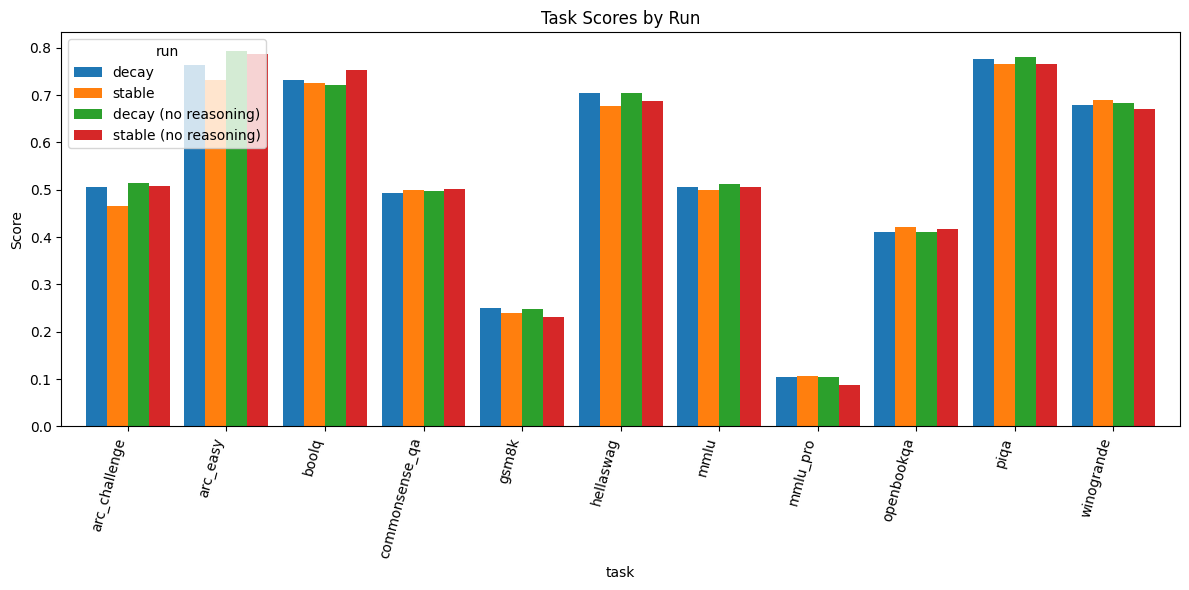

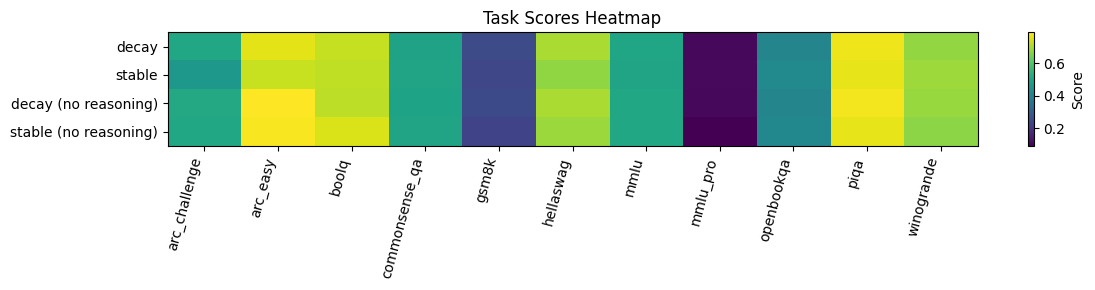

In [ ]:
scores_by_task = m.set_index("task")[run_labels]

ax = scores_by_task.plot(
    kind="bar",
    figsize=(max(12, len(scores_by_task) * max(0.45, 0.18 * len(run_labels))), 6),
    width=0.85,
)
ax.set_ylabel("Score")
ax.set_title("Task Scores by Run")
ax.legend(title="run")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

if len(run_labels) == 2:
    baseline_label, candidate_label = run_labels
    delta_df = m.assign(delta=m[candidate_label] - m[baseline_label]).sort_values("delta", ascending=False)

    plt.figure(figsize=(max(10, len(delta_df) * 0.4), 6))
    colors = ["#2ca02c" if delta >= 0 else "#d62728" for delta in delta_df["delta"]]
    plt.bar(delta_df["task"], delta_df["delta"], color=colors)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Delta")
    plt.title(f"Per-task Delta: {candidate_label} - {baseline_label}")
    plt.tight_layout()
    plt.show()
else:
    heatmap = scores_by_task.T

    plt.figure(figsize=(max(12, len(scores_by_task) * 0.45), max(3, len(run_labels) * 0.6)))
    plt.imshow(heatmap.values, aspect="auto", cmap="viridis")
    plt.colorbar(label="Score")
    plt.xticks(range(len(heatmap.columns)), heatmap.columns, rotation=75, ha="right")
    plt.yticks(range(len(heatmap.index)), heatmap.index)
    plt.title("Task Scores Heatmap")
    plt.tight_layout()
    plt.show()


In [ ]:
# SFT Delta vs HF
# Set `SFT_DELTA_BASES` above with base run paths or run names.
# This section resolves both `hf` and `sft_openthoughts` automatically
# and computes the per-task delta as `sft - hf`.

In [ ]:
sft_delta_labels, sft_delta_m, sft_delta_long, sft_delta_pairs, sft_delta_summary = build_sft_delta(SFT_DELTA_BASES)
sft_delta_m

,task,decay,stable,decay (no reasoning),stable (no reasoning)
0,arc_challenge,-0.044369,-0.021331,-0.145904,-0.143345
1,arc_easy,-0.154461,-0.103535,-0.388889,-0.392677
2,boolq,0.034557,0.028135,-0.099694,-0.131498
3,commonsense_qa,-0.240786,-0.126945,-0.299754,-0.303849
4,gsm8k,0.429871,0.466262,0.038666,0.125853
5,hellaswag,0.010556,0.013543,0.003983,0.003485
6,mmlu,-0.106822,-0.020225,-0.265204,-0.251460
7,mmlu_pro,0.159408,0.153341,0.100898,0.134142
8,openbookqa,-0.002000,-0.018000,-0.002000,-0.010000
9,piqa,-0.021219,-0.028292,-0.047334,-0.043526


In [ ]:
selected_sft_delta_run = sft_delta_labels[0]
sft_delta_pairs[selected_sft_delta_run][["task", "hf", "sft", "delta"]]

,task,hf,sft,delta
0,gsm8k,0.249431,0.679303,0.429871
1,mmlu_pro,0.104388,0.263797,0.159408
2,boolq,0.730887,0.765443,0.034557
3,hellaswag,0.703446,0.714001,0.010556
4,winogrande,0.679558,0.678769,-0.000789
5,openbookqa,0.410000,0.408000,-0.002000
6,piqa,0.775843,0.754625,-0.021219
7,arc_challenge,0.506826,0.462457,-0.044369
8,mmlu,0.505911,0.399088,-0.106822
9,arc_easy,0.764310,0.609848,-0.154461


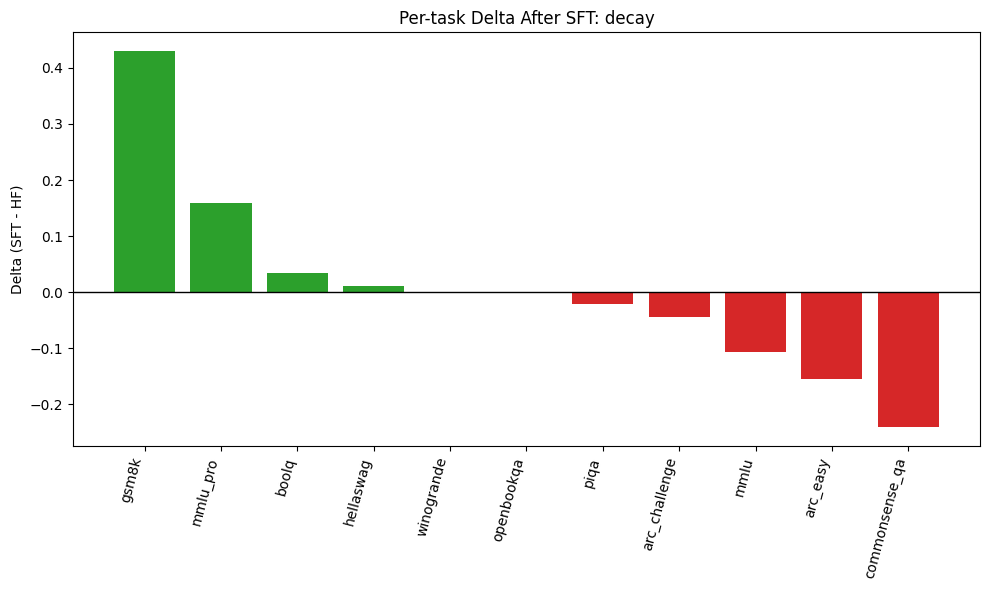

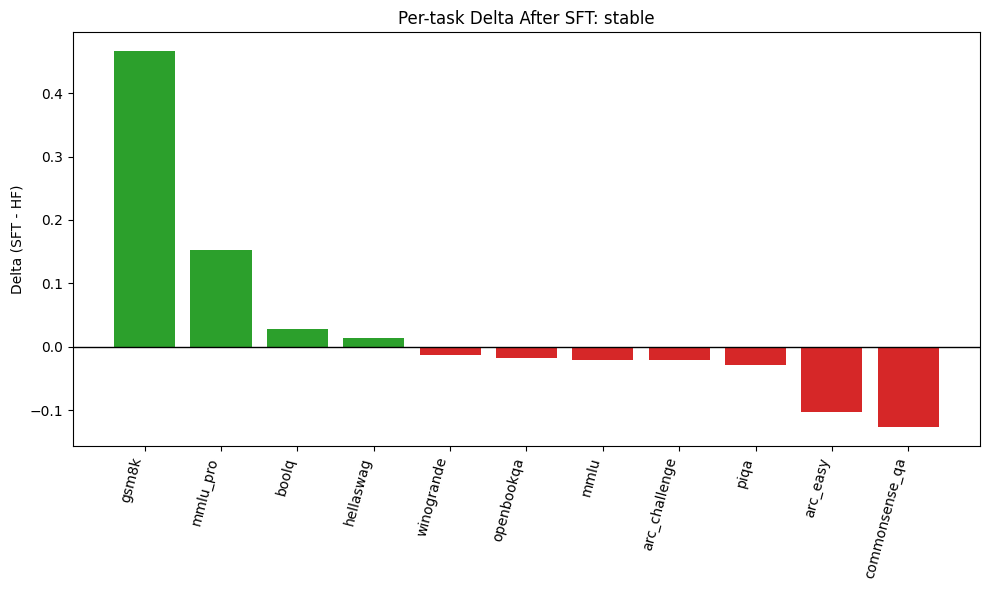

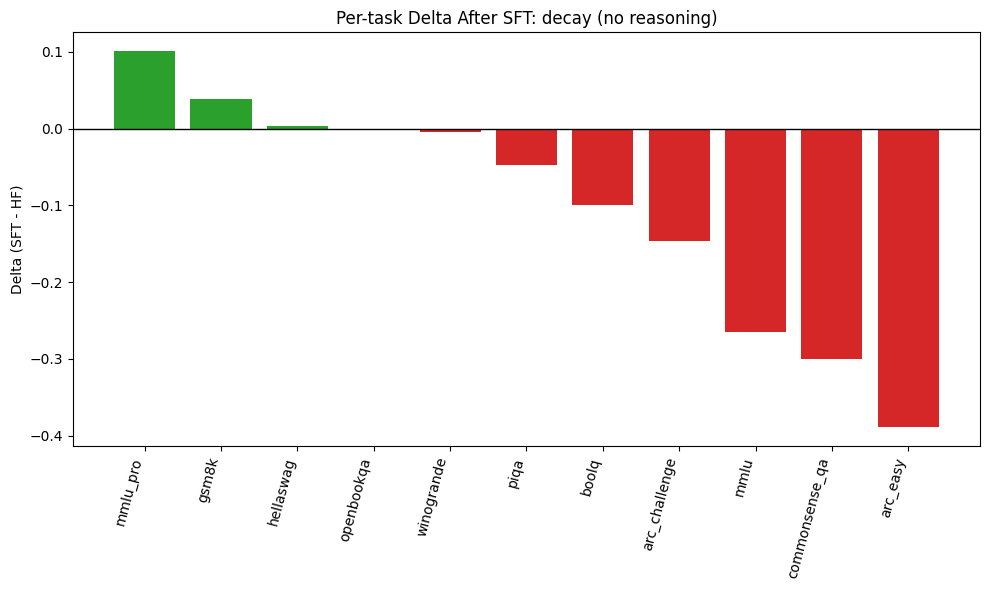

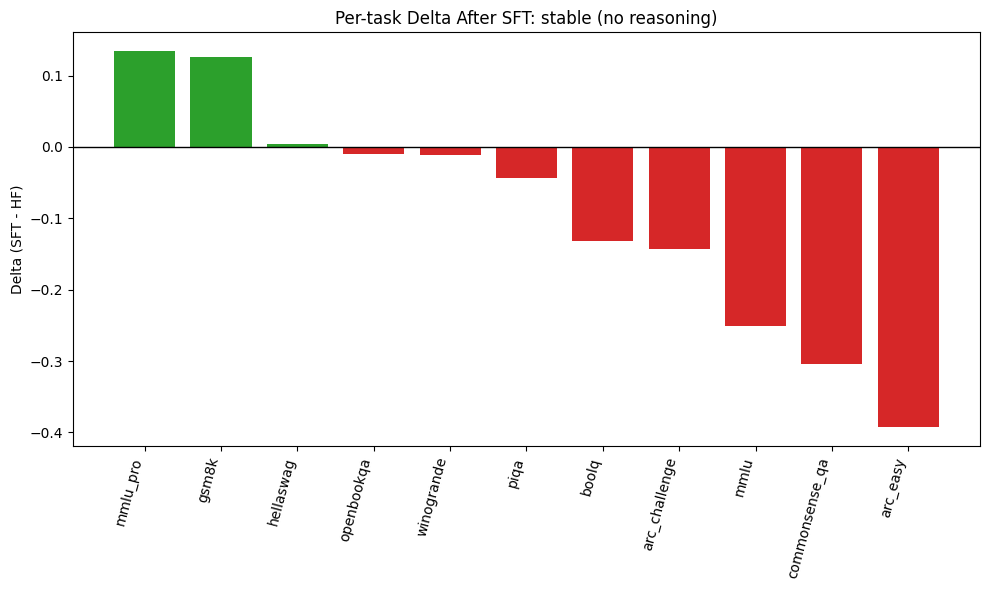

In [ ]:
for label in sft_delta_labels:
    delta_df = sft_delta_pairs[label][["task", "delta"]].sort_values("delta", ascending=False)
    plt.figure(figsize=(max(10, len(delta_df) * 0.4), 6))
    colors = ["#2ca02c" if delta >= 0 else "#d62728" for delta in delta_df["delta"]]
    plt.bar(delta_df["task"], delta_df["delta"], color=colors)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Delta (SFT - HF)")
    plt.title(f"Per-task Delta After SFT: {label}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Base Model vs Midtrained Models
# Uses the single shared pretrained base model at `BASE_MODEL_ROOT`
# and computes per-task delta as `midtrained - base`.

In [ ]:
base_reference_spec = {"base_path": BASE_MODEL_ROOT, "eval_target": "hf"}
base_vs_midtrain_labels, base_vs_midtrain_m, base_vs_midtrain_pairs = build_delta_against_reference(
    base_reference_spec,
    BASE_VS_MIDTRAIN_SPECS,
)
base_vs_midtrain_m

,task,decay,stable,decay (no reasoning),stable (no reasoning)
0,arc_challenge,0.020478,-0.021331,0.028157,0.021331
1,arc_easy,0.007155,-0.024411,0.035774,0.029040
2,boolq,-0.048624,-0.054740,-0.058104,-0.026300
3,commonsense_qa,-0.037674,-0.031122,-0.033579,-0.029484
4,gsm8k,-0.069750,-0.080364,-0.072024,-0.087945
5,hellaswag,-0.015634,-0.042123,-0.015336,-0.032264
6,mmlu,-0.020795,-0.027987,-0.014599,-0.019798
7,mmlu_pro,-0.001579,0.001662,-0.001995,-0.017453
8,openbookqa,-0.038000,-0.026000,-0.038000,-0.030000
9,piqa,-0.007073,-0.016322,-0.002720,-0.016866


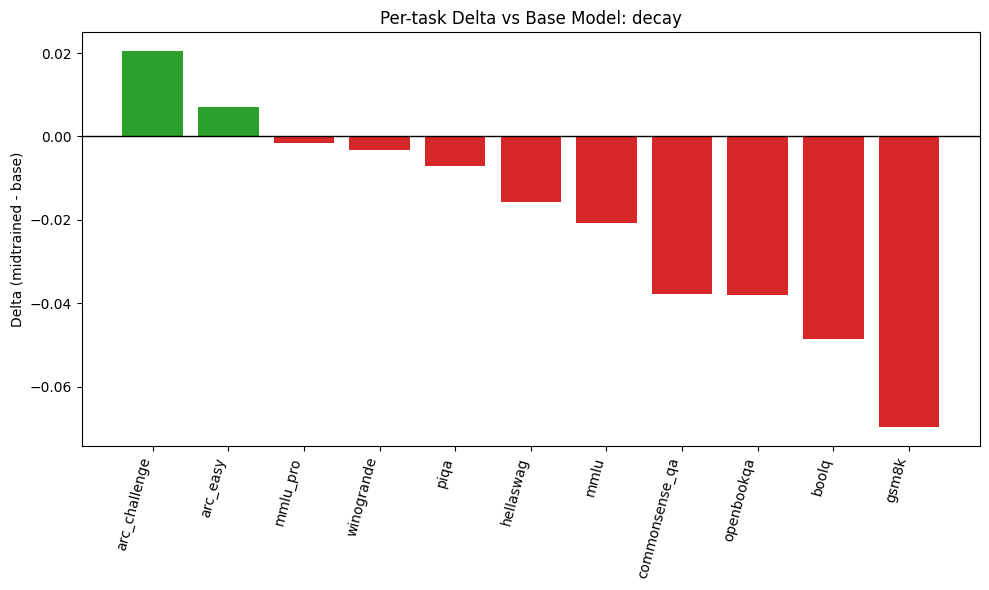

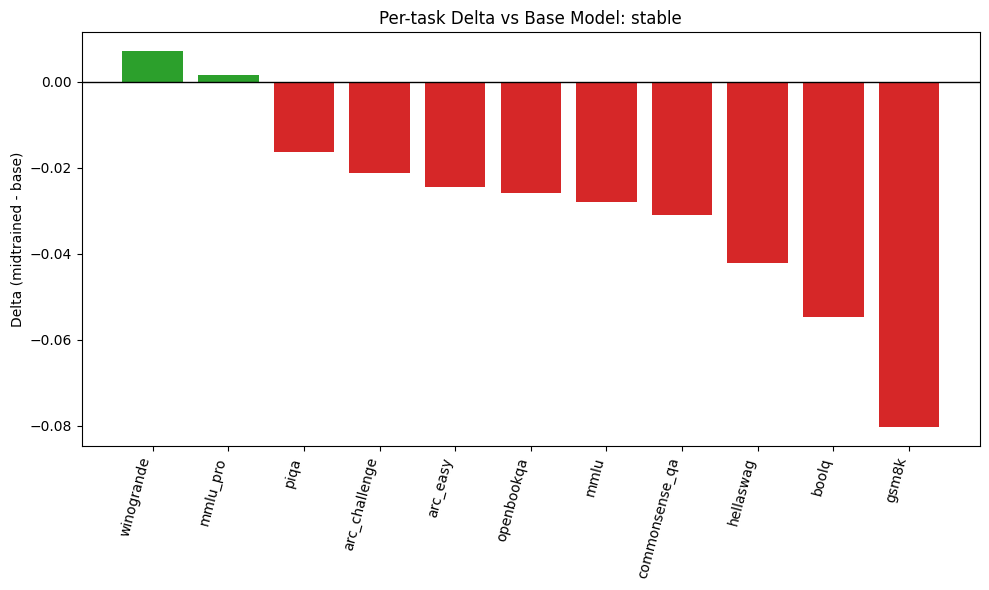

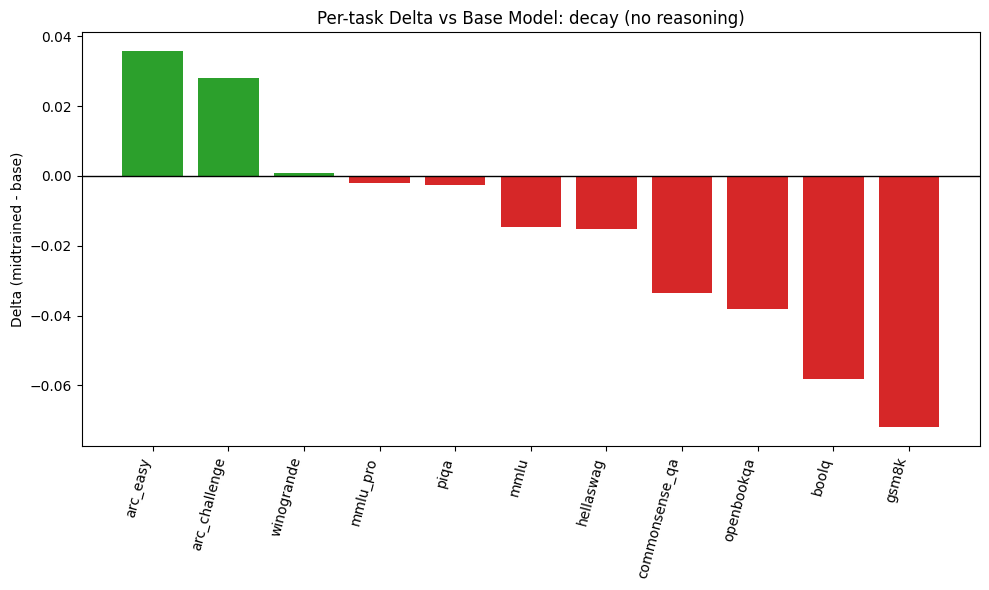

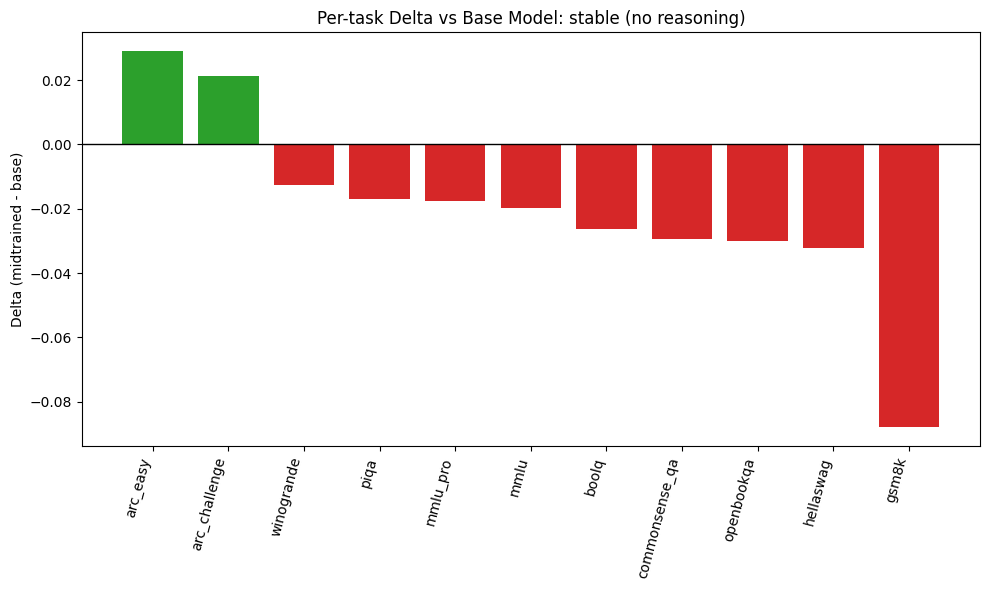

In [ ]:
for label in base_vs_midtrain_labels:
    delta_df = base_vs_midtrain_pairs[label][["task", "delta"]].sort_values("delta", ascending=False)
    plt.figure(figsize=(max(10, len(delta_df) * 0.4), 6))
    colors = ["#2ca02c" if delta >= 0 else "#d62728" for delta in delta_df["delta"]]
    plt.bar(delta_df["task"], delta_df["delta"], color=colors)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Delta (midtrained - base)")
    plt.title(f"Per-task Delta vs Base Model: {label}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Base Model vs SFT Models
# Uses the single shared pretrained base model at `BASE_MODEL_ROOT`
# and computes per-task delta as `sft - base`.

In [ ]:
base_reference_spec = {"base_path": BASE_MODEL_ROOT, "eval_target": "hf"}
base_vs_sft_labels, base_vs_sft_m, base_vs_sft_pairs = build_delta_against_reference(
    base_reference_spec,
    BASE_VS_SFT_SPECS,
)
base_vs_sft_m

,task,decay,stable,decay (no reasoning),stable (no reasoning)
0,arc_challenge,-0.023891,-0.042662,-0.117747,-0.122014
1,arc_easy,-0.147306,-0.127946,-0.353114,-0.363636
2,boolq,-0.014067,-0.026606,-0.157798,-0.157798
3,commonsense_qa,-0.278460,-0.158067,-0.333333,-0.333333
4,gsm8k,0.360121,0.385898,-0.033359,0.037908
5,hellaswag,-0.005079,-0.028580,-0.011352,-0.028779
6,mmlu,-0.127617,-0.048213,-0.279803,-0.271258
7,mmlu_pro,0.157829,0.155003,0.098903,0.116689
8,openbookqa,-0.040000,-0.044000,-0.040000,-0.040000
9,piqa,-0.028292,-0.044614,-0.050054,-0.060392


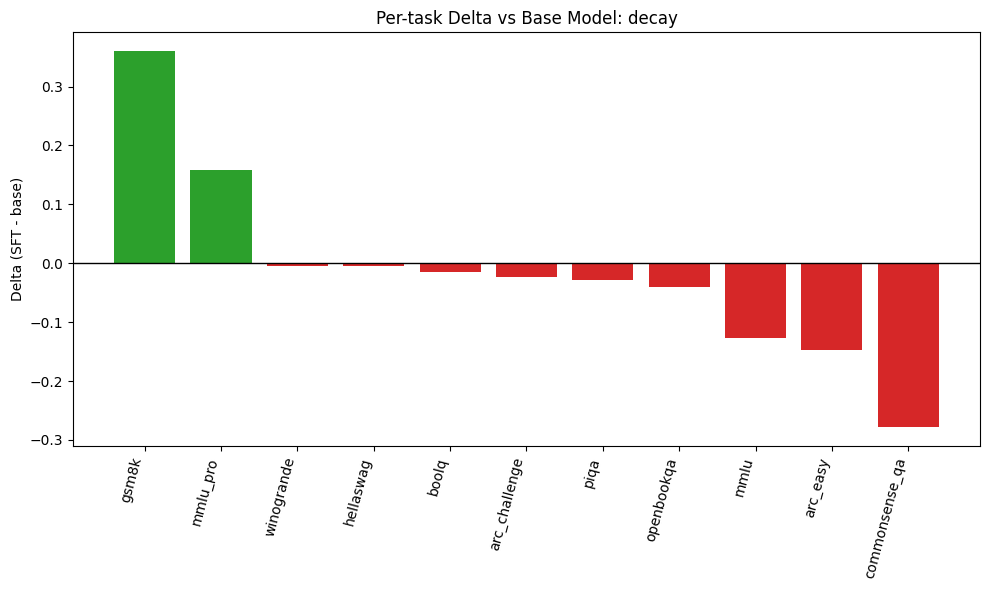

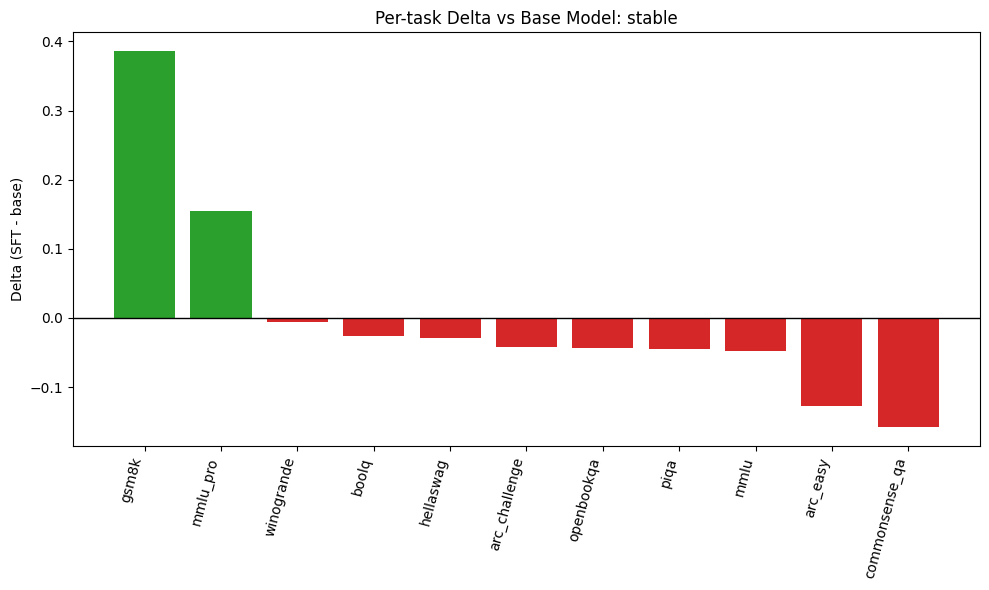

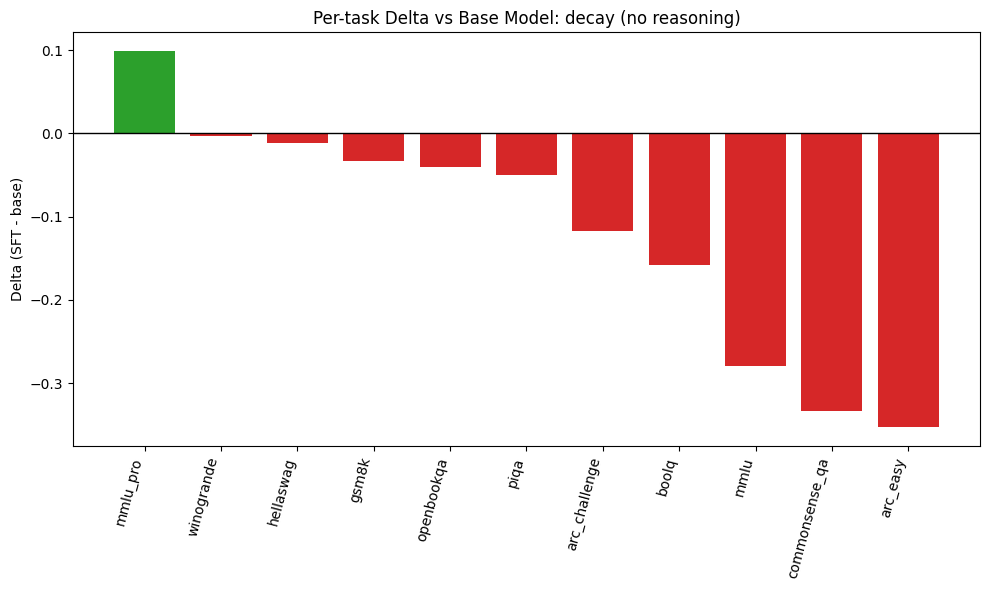

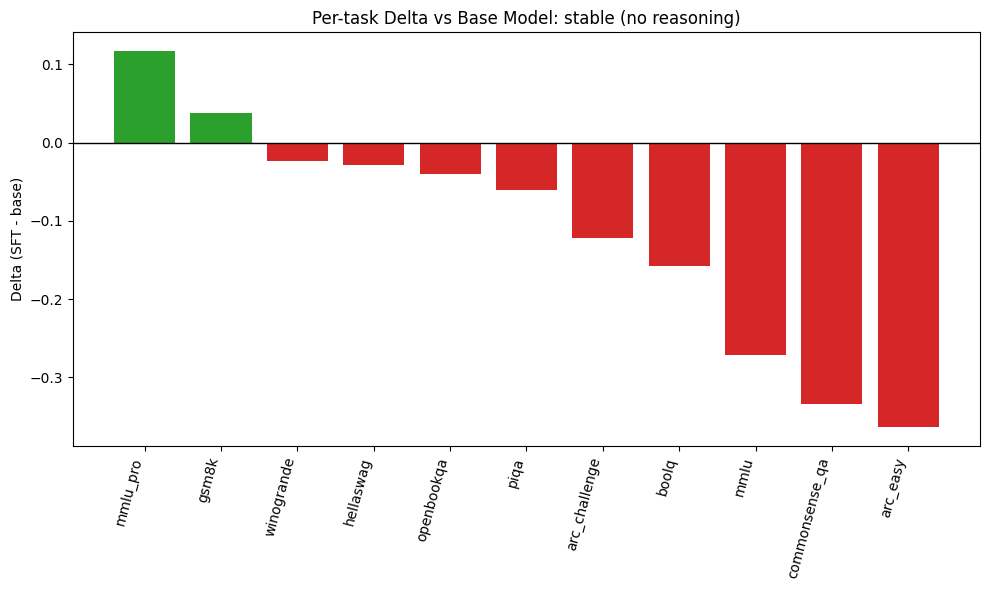

In [ ]:
for label in base_vs_sft_labels:
    delta_df = base_vs_sft_pairs[label][["task", "delta"]].sort_values("delta", ascending=False)
    plt.figure(figsize=(max(10, len(delta_df) * 0.4), 6))
    colors = ["#2ca02c" if delta >= 0 else "#d62728" for delta in delta_df["delta"]]
    plt.bar(delta_df["task"], delta_df["delta"], color=colors)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Delta (SFT - base)")
    plt.title(f"Per-task Delta vs Base Model: {label}")
    plt.tight_layout()
    plt.show()